In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from biomart import BiomartServer

In [3]:
import io

In [4]:
DE_results = pd.read_csv('Day_10_DEG_df.csv', index_col = 0)
DE_results

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GeneID,,,,,,
WASH7P,435.021784,0.063040,0.177744,0.354667,0.722839,0.948424
nan ENSG00000241860,207.690701,-0.204948,0.268906,-0.762156,0.445967,0.858362
CICP27,32.186670,-0.457597,0.424983,-1.076741,0.281596,0.759498
nan ENSG00000308579,94.246903,-0.790661,0.315992,-2.502156,0.012344,0.238582
nan ENSG00000268903,608.638480,-0.503366,0.322131,-1.562613,0.118144,0.581442
...,...,...,...,...,...,...
ND4,272422.517216,0.205953,0.241587,0.852501,0.393936,0.832502
ND5,86790.014663,0.222051,0.196828,1.128145,0.259259,0.744215
ND6,17494.037394,0.227004,0.202284,1.122201,0.261777,0.745530


In [30]:
vsd_Counts = pd.read_csv('DESeq_vsd_basic_multimapping_counts.csv', index_col = 0)
vsd_Counts = vsd_Counts [["B2 day 10", "B11 day 10", "F12 day 10", "C3 day 10", "B10 day 10", "E11 day 10"]]
vsd_Counts

,B2 day 10,B11 day 10,F12 day 10,C3 day 10,B10 day 10,E11 day 10
symbol,,,,,,
WASH7P,8.748866,8.926380,8.636121,8.769469,8.865426,8.842633
nan ENSG00000241860,8.300789,8.476177,7.969442,8.067598,7.981038,8.308832
CICP27,6.940446,7.284466,6.851483,6.770522,6.851387,6.973230
nan ENSG00000308579,7.632577,7.996094,7.679121,7.276981,7.135428,7.585950
nan ENSG00000268903,8.909138,9.798267,9.712776,9.076767,9.155516,9.072970
...,...,...,...,...,...,...
ND4,17.833873,18.167845,17.048108,18.123352,17.885959,17.858512
ND5,16.424596,16.251060,15.803795,16.494520,16.309313,16.403713
ND6,14.137774,13.883366,13.517639,14.168306,14.016719,14.092467


In [31]:
raw_Counts = pd.read_csv('gene_counts_basic_multimapping_trimmed_filtered_symboled.csv', index_col = 0)
raw_Counts = raw_Counts [["B2 day 10", "B11 day 10", "F12 day 10", "C3 day 10", "B10 day 10", "E11 day 10"]]
raw_Counts

,B2 day 10,B11 day 10,F12 day 10,C3 day 10,B10 day 10,E11 day 10
symbol,,,,,,
WASH7P,336,488,303,353,372,318
nan ENSG00000241860,221,325,157,180,159,194
CICP27,39,84,33,29,33,36
nan ENSG00000308579,107,201,113,69,54,88
nan ENSG00000268903,387,998,750,461,477,388
...,...,...,...,...,...,...
ND4,239034,374317,138389,301363,247488,211769
ND5,89927,99034,58351,97368,82899,77193
ND6,18340,19077,11875,19324,16832,15476


In [32]:
# Get significantly upregulated and downregulated genes
DE_results['significant'] = DE_results['padj'] < 0.05

DE_results['TwoFoldUpregulation'] = (DE_results['log2FoldChange'] > 1)
DE_results['TwoFoldDownregulation'] = (DE_results['log2FoldChange'] < -1)

DE_results['SignificantUpregulation'] = (DE_results['significant'] == True) & (DE_results['TwoFoldUpregulation'] == True)
DE_results['SignificantDownregulation'] = (DE_results['significant'] == True) & (DE_results['TwoFoldDownregulation'] == True)

DE_results_SignificantUpregulation = DE_results[DE_results['SignificantUpregulation'] == True]
DE_results_SignificantDownregulation = DE_results[DE_results['SignificantDownregulation'] == True]

In [33]:
# Sort the DEGs based on their fold change
DE_results_SignificantUpregulation_sorted = DE_results_SignificantUpregulation.sort_values('log2FoldChange', ascending = False)
DE_results_SignificantDownregulation_sorted = DE_results_SignificantDownregulation.sort_values('log2FoldChange', ascending = True)
SignificantUpregulated_list = DE_results_SignificantUpregulation_sorted.index.tolist()
SignificantDownregulated_list = DE_results_SignificantDownregulation_sorted.index.tolist()

In [34]:
# Get expression of DEGs from the vsd Count matrix
vsd_Counts_sigup = vsd_Counts.loc[SignificantUpregulated_list]
vsd_Counts_sigdown = vsd_Counts.loc[SignificantDownregulated_list]

In [35]:
# Get expression of DEGs from the raw Count matrix
raw_Counts_sigup = raw_Counts.loc[SignificantUpregulated_list]
raw_Counts_sigdown = raw_Counts.loc[SignificantDownregulated_list]

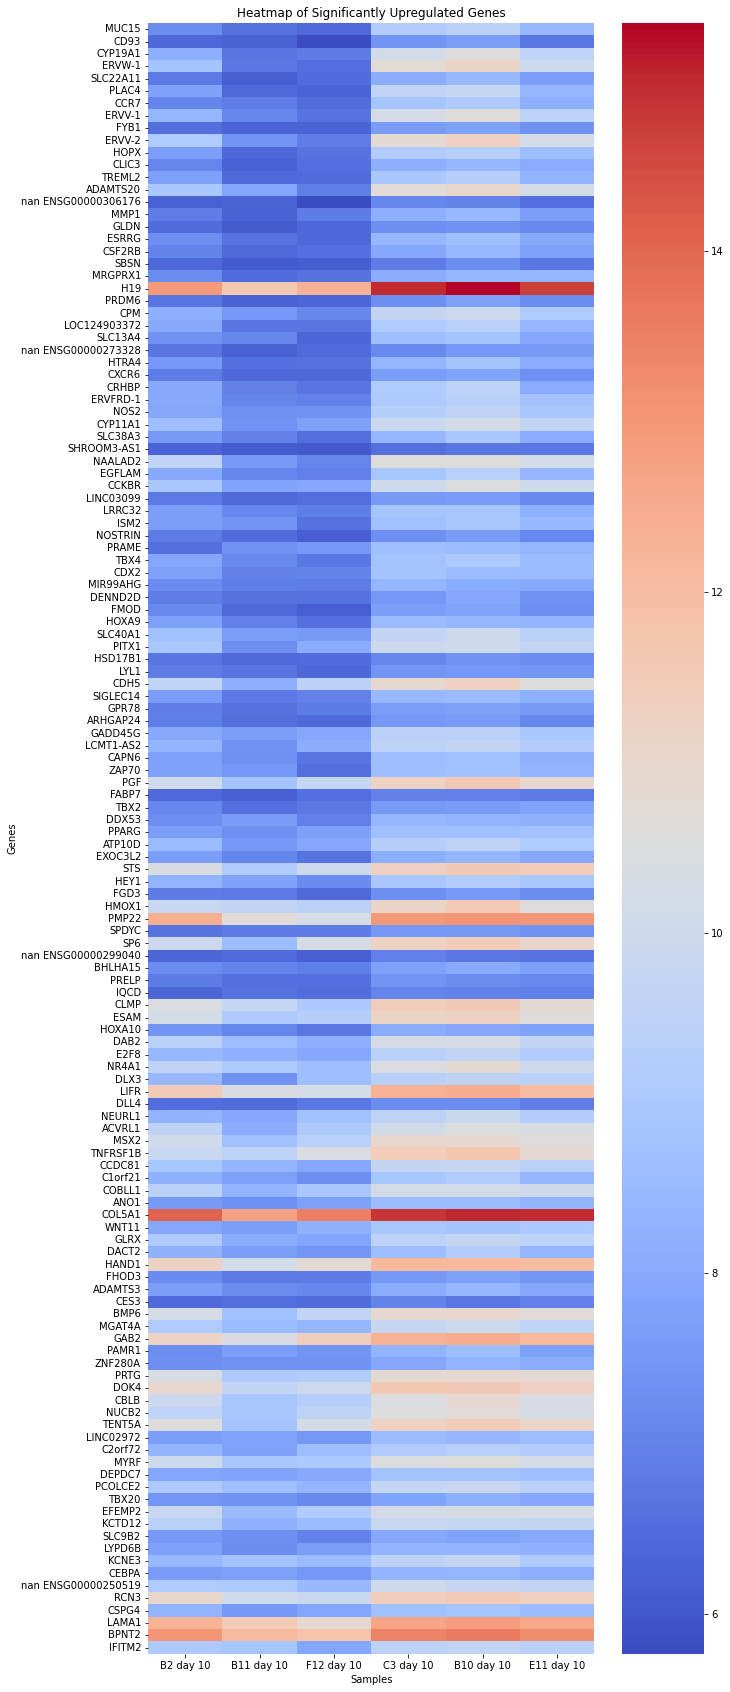

In [49]:
Min_value = vsd_Counts_sigup.min().min()
Max_value = vsd_Counts_sigup.max().max()

# Plot heatmap of significantly upregulated genes
plt.figure(figsize=(10,30))
sns.heatmap(vsd_Counts_sigup, cmap='coolwarm', yticklabels=SignificantUpregulated_list, vmin = Min_value, vmax = Max_value)
plt.title('Heatmap of Significantly Upregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

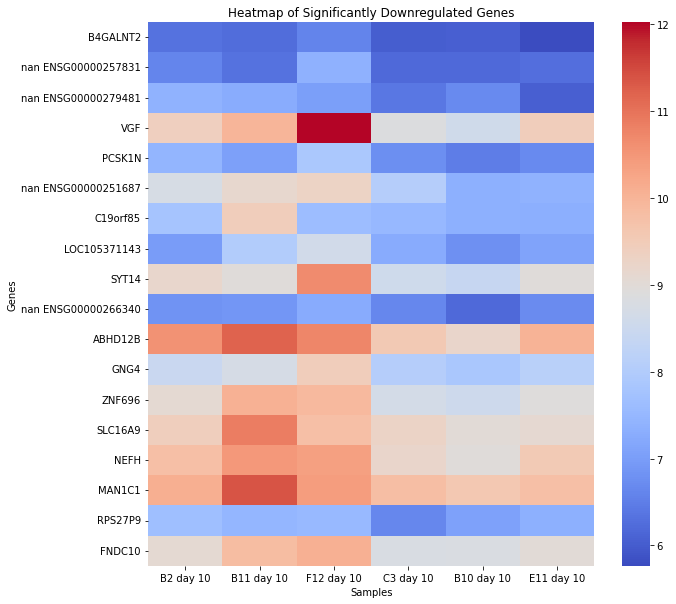

In [38]:
Min_value = vsd_Counts_sigdown.min().min()
Max_value = vsd_Counts_sigdown.max().max()

# Plot heatmap of significantly downregulated genes
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_sigdown, cmap='coolwarm', yticklabels=SignificantDownregulated_list, vmin = Min_value, vmax = Max_value)
plt.title('Heatmap of Significantly Downregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

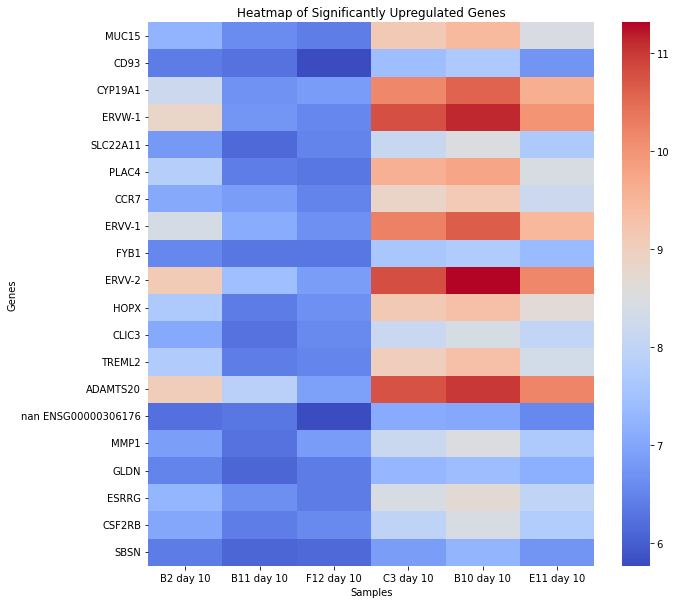

In [39]:
# Plot heatmap of top 20 significantly upregulated genes based on the log2 fold change
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_sigup[0:20], cmap='coolwarm', yticklabels=SignificantUpregulated_list[0:20])
plt.title('Heatmap of Significantly Upregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

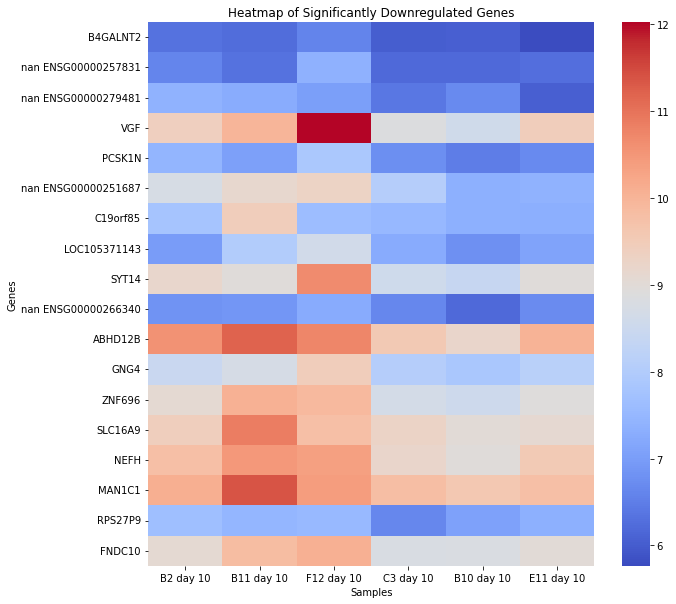

In [40]:
# Plot heatmap of top 20 significantly downregulated genes based on the log2 fold change
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_sigdown[0:20], cmap='coolwarm', yticklabels=SignificantDownregulated_list[0:20])
plt.title('Heatmap of Significantly Downregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

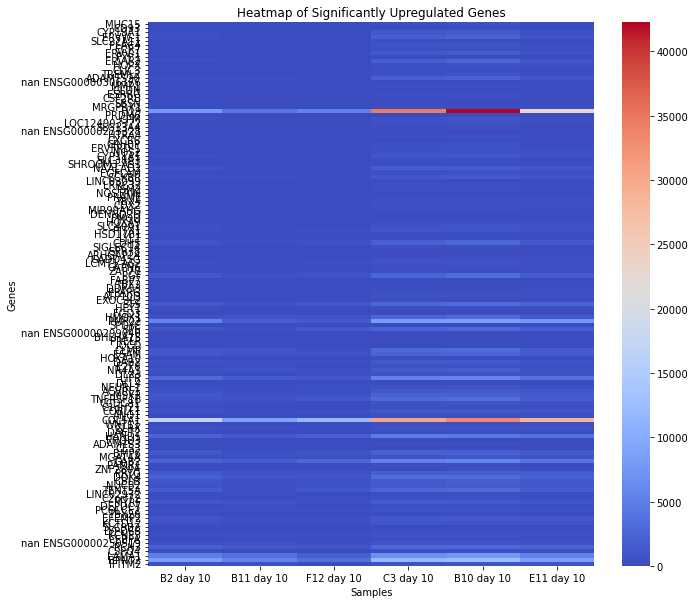

In [41]:
# Plot heatmap from the raw count matrix
plt.figure(figsize=(10,10))
sns.heatmap(raw_Counts_sigup, cmap='coolwarm', yticklabels=SignificantUpregulated_list)
plt.title('Heatmap of Significantly Upregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

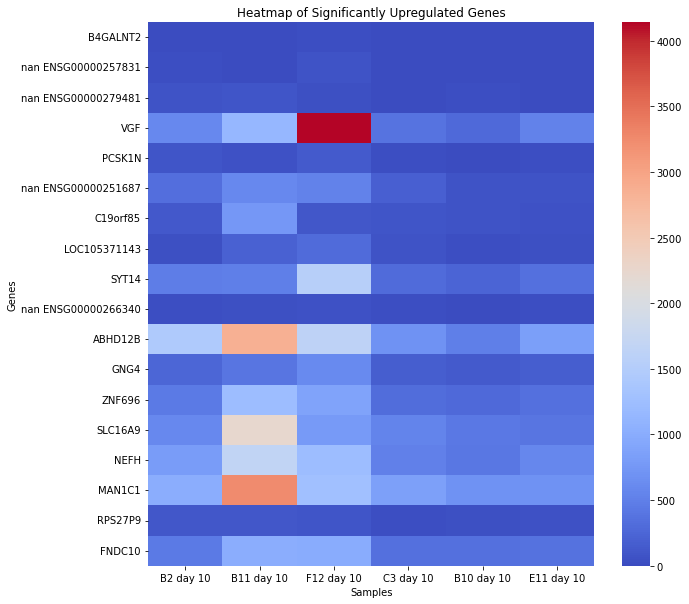

In [42]:
# Plot heatmap from the raw count matrix
plt.figure(figsize=(10,10))
sns.heatmap(raw_Counts_sigdown, cmap='coolwarm', yticklabels=SignificantDownregulated_list)
plt.title('Heatmap of Significantly Upregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

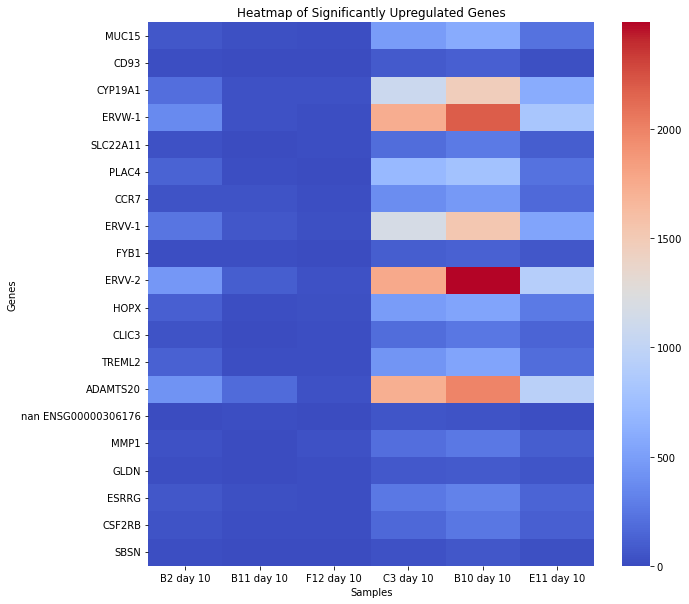

In [43]:
# Plot heatmap from the raw count matrix
plt.figure(figsize=(10,10))
sns.heatmap(raw_Counts_sigup[0:20], cmap='coolwarm', yticklabels=SignificantUpregulated_list[0:20])
plt.title('Heatmap of Significantly Upregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

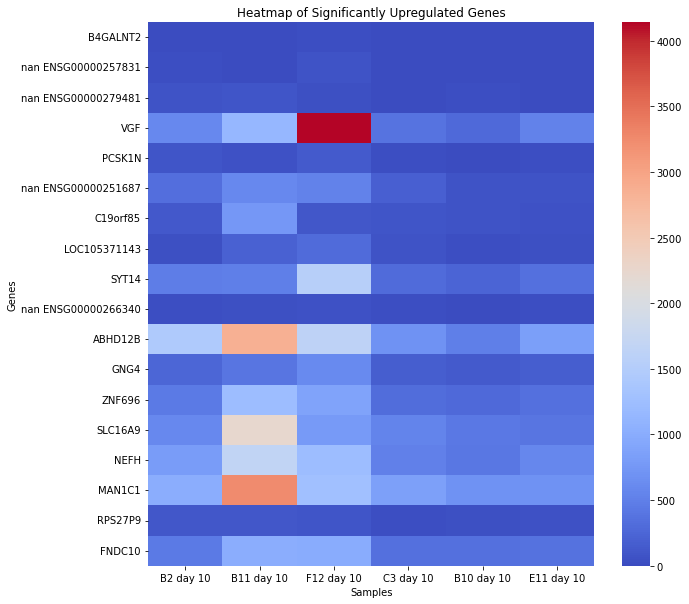

In [44]:
# Plot heatmap from the raw count matrix
plt.figure(figsize=(10,10))
sns.heatmap(raw_Counts_sigdown[0:20], cmap='coolwarm', yticklabels=SignificantDownregulated_list[0:20])
plt.title('Heatmap of Significantly Upregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

In [45]:
# Sort DEGs based on the p-value
DE_results_SignificantUpregulation_sorted_p = DE_results_SignificantUpregulation.sort_values('pvalue', ascending = True)
DE_results_SignificantDownregulation_sorted_p = DE_results_SignificantDownregulation.sort_values('pvalue', ascending = True)
SignificantUpregulated_list_p = DE_results_SignificantUpregulation_sorted_p.index.tolist()
SignificantDownregulated_list_p = DE_results_SignificantDownregulation_sorted_p.index.tolist()

In [46]:
# Get expression of DEGs sorted by the p-value from the vsd count matrix
vsd_Counts_sigup_p = vsd_Counts.loc[SignificantUpregulated_list_p]
vsd_Counts_sigdown_p = vsd_Counts.loc[SignificantDownregulated_list_p]

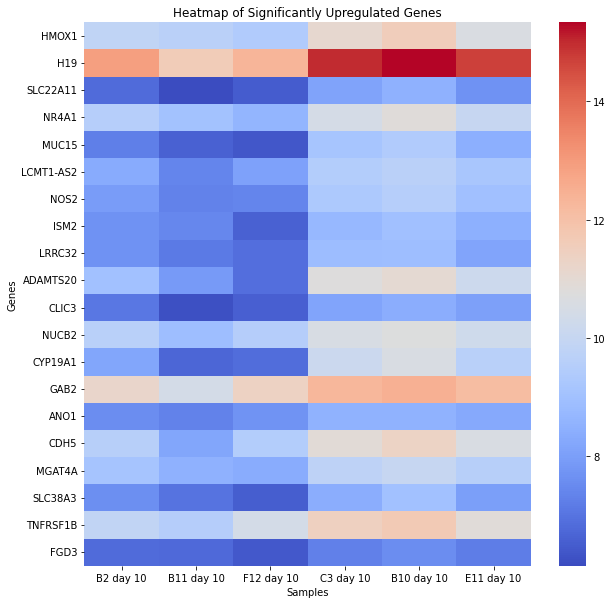

In [47]:
# Plot heatmap of top 20 significantly upregulated genes sorted by the p-value
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_sigup_p[0:20], cmap='coolwarm', yticklabels=SignificantUpregulated_list_p[0:20])
plt.title('Heatmap of Significantly Upregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

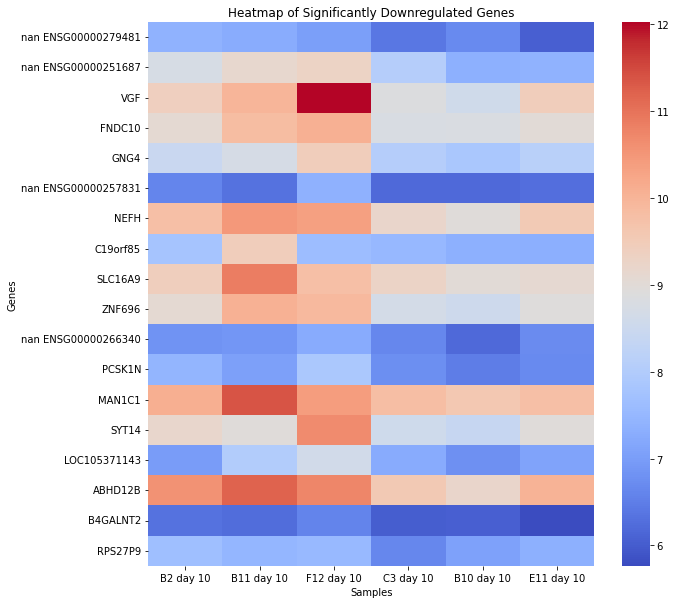

In [71]:
# Plot heatmap of top 20 significantly downregulated genes sorted by the p-value
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_sigdown_p[0:20], cmap='coolwarm', yticklabels=SignificantDownregulated_list_p[0:20])
plt.title('Heatmap of Significantly Downregulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

# Plot Heatmaps of pluripotency markers

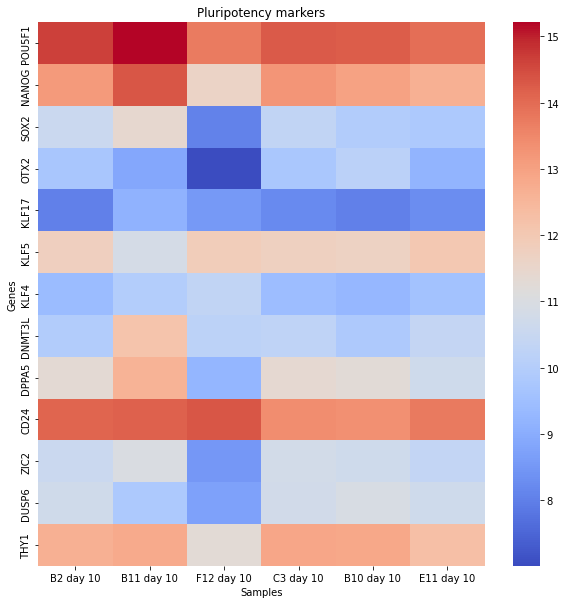

In [50]:
# Plot a mix of pan- naive- and primed-pluripotency markers
Pluripotency_list = ['POU5F1', 'NANOG', 'SOX2', 'OTX2', 'KLF17', 'KLF5', 'KLF4', 'DNMT3L', 'DPPA5', 'CD24', 'ZIC2', 'DUSP6', 'THY1']
vsd_Counts_pluripotency = vsd_Counts.loc[Pluripotency_list]
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_pluripotency, cmap='coolwarm', yticklabels=Pluripotency_list)
plt.title('Pluripotency markers')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

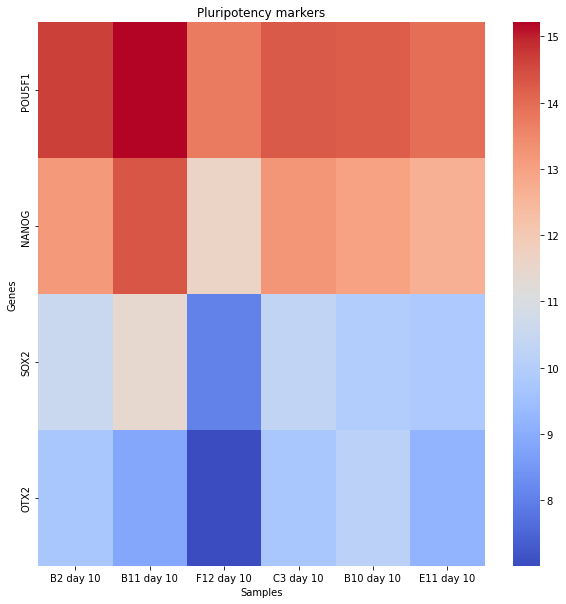

In [51]:
# Plot pan-pluripotency markers
Pluripotency_list = ['POU5F1', 'NANOG', 'SOX2', 'OTX2']
vsd_Counts_pluripotency = vsd_Counts.loc[Pluripotency_list]
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_pluripotency, cmap='coolwarm', yticklabels=Pluripotency_list)
plt.title('Pluripotency markers')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

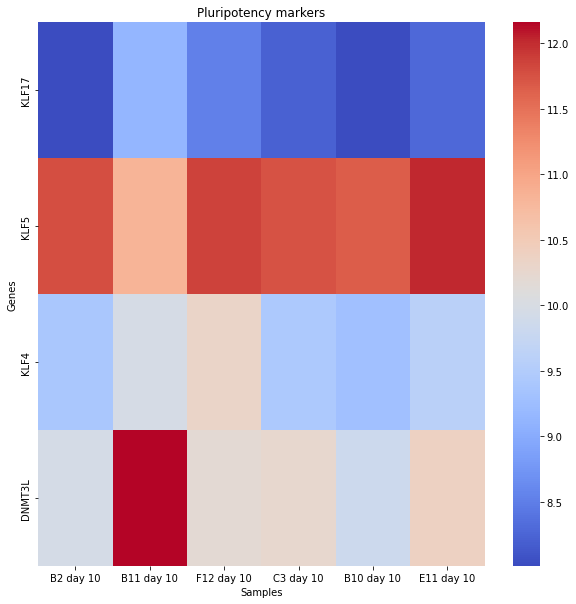

In [52]:
# Plot naive-pluripotency markers
Pluripotency_list = ['KLF17', 'KLF5', 'KLF4', 'DNMT3L']
vsd_Counts_pluripotency = vsd_Counts.loc[Pluripotency_list]
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_pluripotency, cmap='coolwarm', yticklabels=Pluripotency_list)
plt.title('Pluripotency markers')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

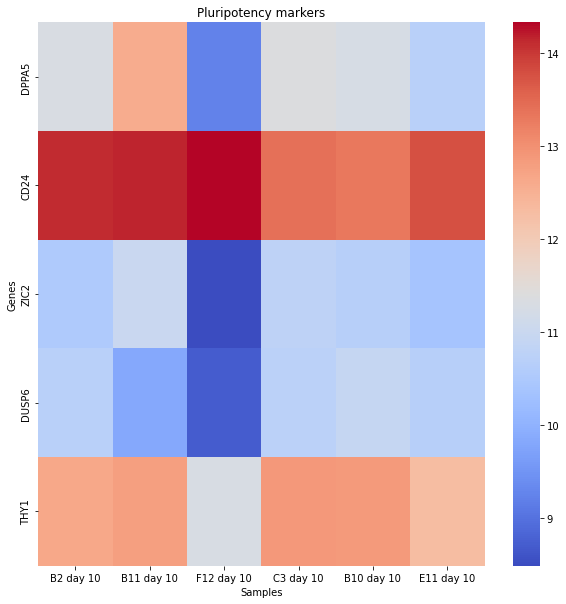

In [53]:
# Plot primed-pluripotency markers
Pluripotency_list = ['DPPA5', 'CD24', 'ZIC2', 'DUSP6', 'THY1']
vsd_Counts_pluripotency = vsd_Counts.loc[Pluripotency_list]
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_pluripotency, cmap='coolwarm', yticklabels=Pluripotency_list)
plt.title('Pluripotency markers')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

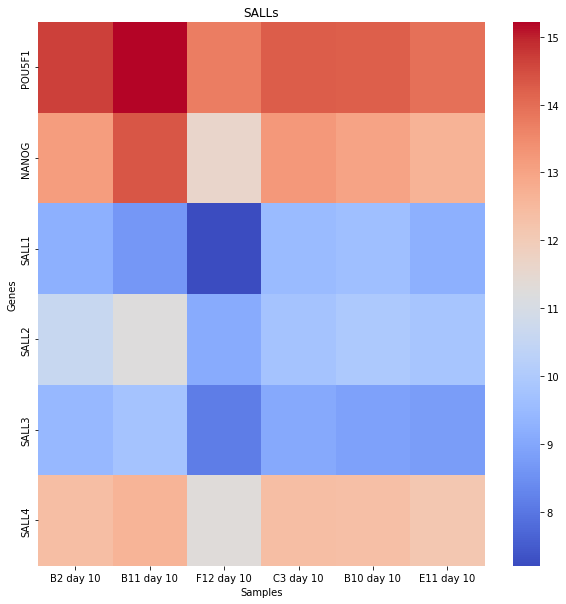

In [72]:
# Plot the expression of all SALL factors
Pluripotency_list = ['POU5F1', 'NANOG', 'SALL1', 'SALL2', 'SALL3', 'SALL4']
vsd_Counts_pluripotency = vsd_Counts.loc[Pluripotency_list]
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_pluripotency, cmap='coolwarm', yticklabels=Pluripotency_list)
plt.title('SALLs')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

# Check gene expression on p-arm chromosome 12

In [55]:
# Get all the genes on the p-arm of chromosome 12
server = BiomartServer("http://www.ensembl.org/biomart") # Connect to the Ensembl Biomart server
dataset = server.datasets['hsapiens_gene_ensembl'] # Select the human genes dataset

# Define the p-arm of chromosome 12 (positions 1 to 35,000,000)
chrom = '12'
start = 1
end = 35000000  # Approximate centromere position

# Define filters
filters = {
    'chromosome_name': chrom,
    'start': start,
    'end': end
}

# Define attributes to retrieve
attributes = [
    'ensembl_gene_id',
    'external_gene_name',
    'chromosome_name',
    'start_position',
    'end_position',
    'strand',
    'gene_biotype',
    'description'
]

# Perform the query
response = dataset.search({
    'filters': filters,
    'attributes': attributes
})

# Read the response into a pandas DataFrame
genes_df = pd.read_csv(io.StringIO(response.text), sep='\t', header=None)
genes_df.columns = [
    'Ensembl Gene ID',
    'Gene Name',
    'Chromosome',
    'Start Position',
    'End Position',
    'Strand',
    'Gene Biotype',
    'Description'
]

genes_df['Gene Name'] = genes_df['Gene Name'].fillna(genes_df['Ensembl Gene ID'])

genes_df

# Save the DataFrame to a CSV file
genes_df.to_csv('chr12_p_arm_genes.csv', index=False)

In [56]:
# Find the chr12 p-arm genes that are expressed in our dataset 
Chromosome12_p_arm_genes_list = genes_df['Gene Name'].tolist()
Chromosome12_p_arm_genes_list_exist = []
for gene in Chromosome12_p_arm_genes_list:
    if gene in vsd_Counts.index.tolist():
        Chromosome12_p_arm_genes_list_exist.append(gene)

In [58]:
# Sort chr12p expressed genes based on their expression level in the WT
vsd_Counts_12p = vsd_Counts.loc[Chromosome12_p_arm_genes_list_exist]
vsd_Counts_12p_sorted = vsd_Counts_12p.sort_values(by='B2 day 10', ascending=False)

In [61]:
raw_Counts_12p = raw_Counts.loc[Chromosome12_p_arm_genes_list_exist]
raw_Counts_12p_sorted = raw_Counts_12p.sort_values(by='B2 day 10', ascending=False)

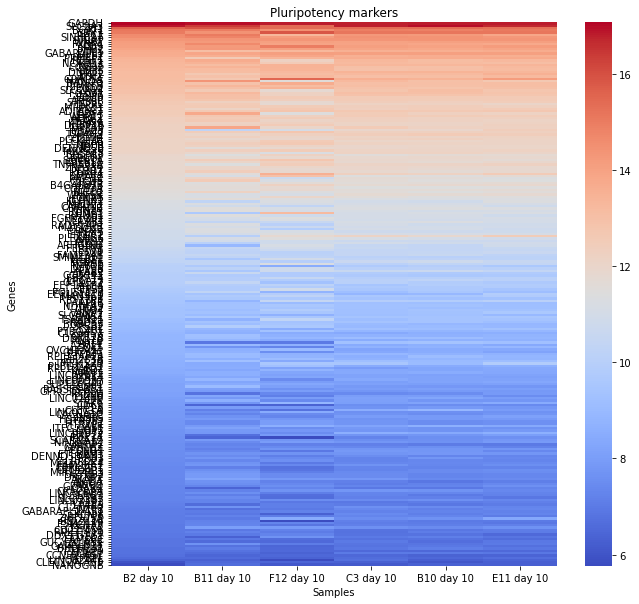

In [62]:
# Plot the expression of all chr12p genes
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_12p_sorted, cmap='coolwarm', yticklabels=vsd_Counts_12p_sorted.index.tolist())
plt.title('Pluripotency markers')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

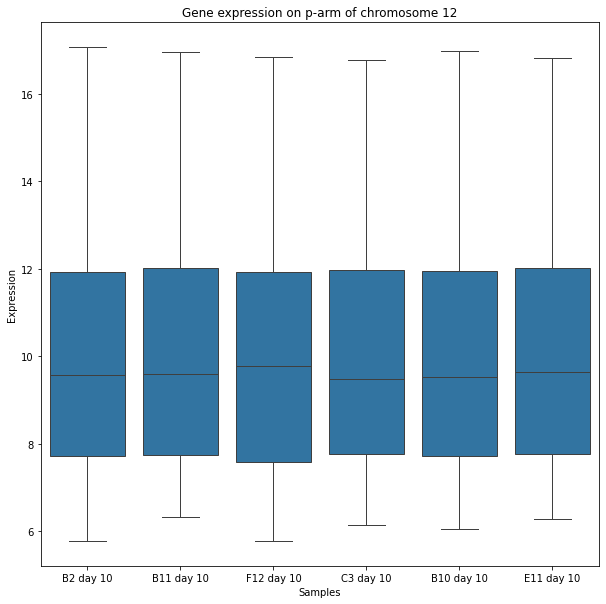

In [63]:
# Box plot of the chr12p gene expression level across different samples
vsd_Counts_12p_melted = vsd_Counts_12p.melt(var_name='Sample', value_name='Expression')
plt.figure(figsize=(10,10))
sns.boxplot(x = 'Sample', y = 'Expression', data=vsd_Counts_12p_melted)
plt.title('Gene expression on p-arm of chromosome 12')
plt.xlabel('Samples')
plt.ylabel('Expression')
plt.show()

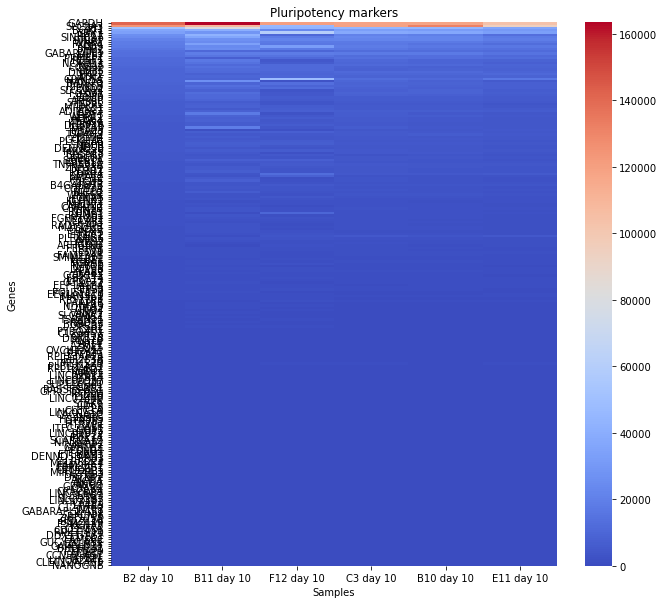

In [64]:
plt.figure(figsize=(10,10))
sns.heatmap(raw_Counts_12p_sorted, cmap='coolwarm', yticklabels=raw_Counts_12p_sorted.index.tolist())
plt.title('Pluripotency markers')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

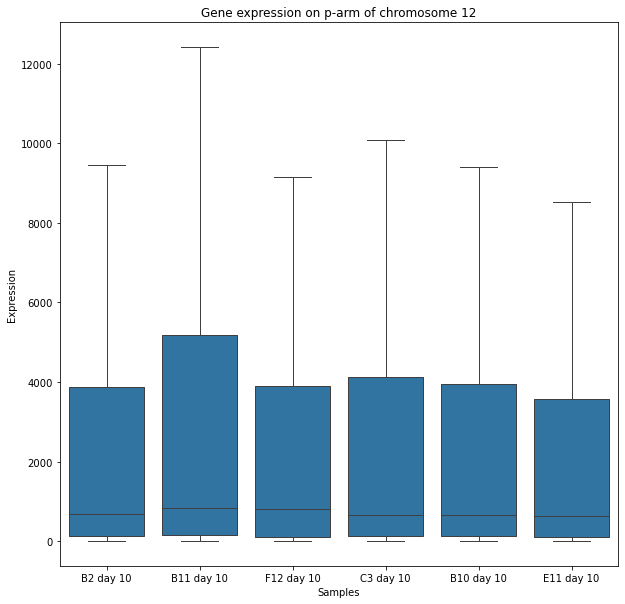

In [65]:
raw_Counts_12p_melted = raw_Counts_12p.melt(var_name='Sample', value_name='Expression')
plt.figure(figsize=(10,10))
sns.boxplot(x = 'Sample', y = 'Expression', data=raw_Counts_12p_melted, showfliers=False)
plt.title('Gene expression on p-arm of chromosome 12')
plt.xlabel('Samples')
plt.ylabel('Expression')
plt.show()

In [66]:
# Find genes on the end of q-arm of chr12
server = BiomartServer("http://www.ensembl.org/biomart") # Connect to the Ensembl Biomart server
dataset = server.datasets['hsapiens_gene_ensembl'] # Select the human genes dataset

chrom = '12'
start = 11300000
end = 133000000  

# Define filters
filters = {
    'chromosome_name': chrom,
    'start': start,
    'end': end
}

# Define attributes to retrieve
attributes = [
    'ensembl_gene_id',
    'external_gene_name',
    'chromosome_name',
    'start_position',
    'end_position',
    'strand',
    'gene_biotype',
    'description'
]

# Perform the query
response = dataset.search({
    'filters': filters,
    'attributes': attributes
})

# Read the response into a pandas DataFrame
genes_df = pd.read_csv(io.StringIO(response.text), sep='\t', header=None)
genes_df.columns = [
    'Ensembl Gene ID',
    'Gene Name',
    'Chromosome',
    'Start Position',
    'End Position',
    'Strand',
    'Gene Biotype',
    'Description'
]

genes_df['Gene Name'] = genes_df['Gene Name'].fillna(genes_df['Ensembl Gene ID'])

genes_df

,Ensembl Gene ID,Gene Name,Chromosome,Start Position,End Position,Strand,Gene Biotype,Description
0,ENSG00000230657,PRB4,12,11307077,11310436,-1,protein_coding,proline rich protein BstNI subfamily 4 [Source...
1,ENSG00000251655,PRB1,12,11351823,11355591,-1,protein_coding,proline rich protein BstNI subfamily 1 [Source...
2,ENSG00000121335,PRB2,12,11391540,11501041,-1,protein_coding,proline rich protein BstNI subfamily 2 [Source...
3,ENSG00000255790,ENSG00000255790,12,11399381,11486708,-1,lncRNA,novel transcript
4,ENSG00000237303,HIGD1AP8,12,11481383,11481656,1,processed_pseudogene,HIG1 hypoxia inducible domain family member 1A...
...,...,...,...,...,...,...,...,...
3298,ENSG00000196458,ZNF605,12,132918306,132956306,-1,protein_coding,zinc finger protein 605 [Source:HGNC Symbol;Ac...
3299,ENSG00000289516,ENSG00000289516,12,132956367,132983710,1,lncRNA,novel transcript
3300,ENSG00000256563,NANOGNBP2,12,132972338,132972890,-1,processed_pseudogene,NANOGNB pseudogene 2 [Source:HGNC Symbol;Acc:H...
3301,ENSG00000198393,ZNF26,12,132986365,133032952,1,protein_coding,zinc finger protein 26 [Source:HGNC Symbol;Acc...


In [68]:
Chromosome12_q_arm_genes_list = genes_df['Gene Name'].tolist()
Chromosome12_q_arm_genes_list_exist = []
for gene in Chromosome12_q_arm_genes_list:
    if gene in vsd_Counts.index.tolist():
        Chromosome12_q_arm_genes_list_exist.append(gene)
        
vsd_Counts_12q = vsd_Counts.loc[Chromosome12_q_arm_genes_list_exist]
vsd_Counts_12q_sorted = vsd_Counts_12q.sort_values(by='B2 day 10', ascending=False)

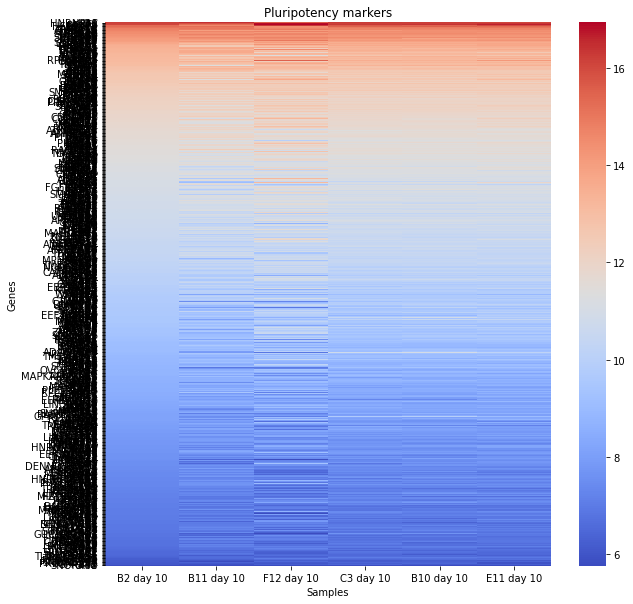

In [69]:
plt.figure(figsize=(10,10))
sns.heatmap(vsd_Counts_12q_sorted, cmap='coolwarm', yticklabels=vsd_Counts_12q_sorted.index.tolist())
plt.title('Pluripotency markers')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()

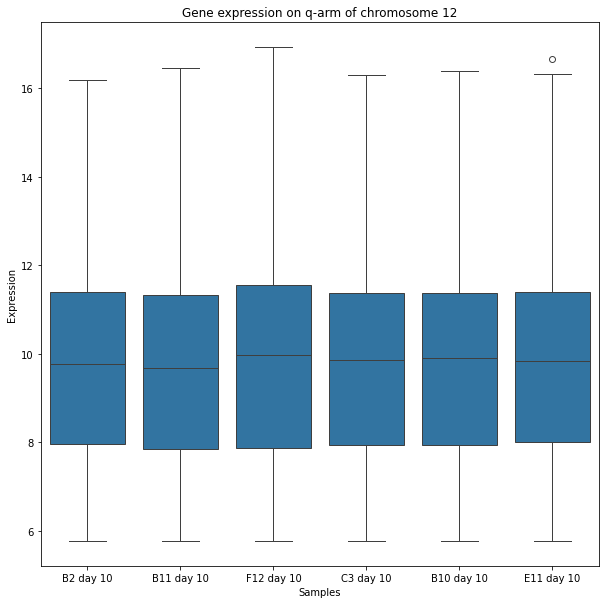

In [70]:
vsd_Counts_12q_melted = vsd_Counts_12q.melt(var_name='Sample', value_name='Expression')
plt.figure(figsize=(10,10))
sns.boxplot(x = 'Sample', y = 'Expression', data=vsd_Counts_12q_melted)
plt.title('Gene expression on q-arm of chromosome 12')
plt.xlabel('Samples')
plt.ylabel('Expression')
plt.show()